In [10]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [41]:
#load mnist data
(train_data,train_label),(test_data,test_label)=keras.datasets.mnist.load_data()
print(train_data[1].shape)

(28, 28)


In [42]:
#define values
n_classes=10
input_shape=(28,28,1)
#Rescale pixel values
train_data2D=train_data.astype("float32")/255
test_data2D=test_data.astype("float32")/255
#Make right dimensions
train_data3D=np.expand_dims(train_data2D,-1)
test_data3D=np.expand_dims(test_data2D,-1)
print(train_data2D[1].shape)

(28, 28)


In [4]:
#Convert labels to matrix with 10 "classes"
train_label=keras.utils.to_categorical(train_label,n_classes)
test_label=keras.utils.to_categorical(test_label,n_classes)
print(train_label[1].shape)

(10,)


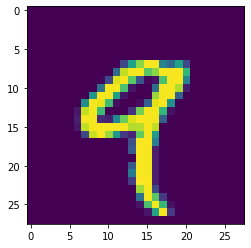

In [7]:
#Show an example image
plt.imshow(train_data[4])
plt.show()

In [12]:
#Define a function to compile and fit the models
def compile_and_fit(model,optimizer=None,max_epochs=15,batch_size=15):
    if optimizer is None:
        optimizer=get_optimizer()
    model.compile(optimizer=optimizer,loss="categorical_crossentropy",metrics=["categorical_crossentropy","accuracy"])
    model.summary()
    history=model.fit(train_data,train_label,batch_size=batch_size,epochs=max_epochs,validation_split=0.1)
    return history  

In [17]:
import keras_tuner as kt

In [31]:
#First build a model with a single hidden layer
#Use a tuner to find optimal parameters for this model
def build_model(hp):
    model=keras.Sequential()
    model.add(keras.layers.Flatten(input_shape=(28,28)))
    #Choose number of neurons in hidden layer
    hp_units=hp.Int("units",min_value=32,max_value=512,step=32)
    model.add(keras.layers.Dense(units=hp_units,activation="relu"))
    model.add(keras.layers.Dense(units=10))
    #Choose learning rate
    hp_lr=hp.Choice("learning_rate",values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_lr),
                loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])
    return model

In [35]:
#Instantiate tuner
tuner=kt.Hyperband(build_model,objective="accuracy", max_epochs=10,factor=3)
#Create a callback to stop trainig early
stop_early=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=5)

INFO:tensorflow:Reloading Oracle from existing project ./untitled_project/oracle.json
INFO:tensorflow:Reloading Tuner from ./untitled_project/tuner0.json


In [36]:
#Find optimal hyperparamters
tuner.search(train_data2D,train_label,epochs=50, validation_split=0.2, callbacks=[stop_early])
best_hps=tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Optimal number of neurons:{best_hps.get('units')}\nOptimal learning rate:{best_hps.get('learning_rate')}")

Trial 12 Complete [00h 01m 25s]
accuracy: 0.9753333330154419

Best accuracy So Far: 0.9928958415985107
Total elapsed time: 00h 08m 00s
INFO:tensorflow:Oracle triggered exit
Optimal number of neurons:{best_hps.get('units')}
Optimal learning rate:{best_hps.get('learning_rate')}


In [38]:
print(f"Optimal number of neurons:{best_hps.get('units')}\nOptimal learning rate:{best_hps.get('learning_rate')}")
print(best_hps)

Optimal number of neurons:448
Optimal learning rate:0.001


In [44]:
#Find optimal number of epochs
trial_model1=tuner.hypermodel.build(best_hps)
history1=trial_model1.fit(test_data2D,test_label,epochs=50,validation_split=0.2)
#Record the validation accuracy for each epoch
val_acc_per_epoch=history1.history["val_accuracy"]
#Find the the epoch at which the validation accuracy is highest
perf_epoch=val_acc_per_epoch.index(max(val_acc_per_epoch)) + 1
print('Best epoch: %d' % (perf_epoch,))

Epoch 1/50
250/250 [==============================] - 1s 4ms/step - loss: 0.4617 - accuracy: 0.8650 - val_loss: 0.2135 - val_accuracy: 0.9355
Epoch 2/50
250/250 [==============================] - 1s 3ms/step - loss: 0.1978 - accuracy: 0.9392 - val_loss: 0.1697 - val_accuracy: 0.9425
Epoch 3/50
250/250 [==============================] - 1s 3ms/step - loss: 0.1194 - accuracy: 0.9670 - val_loss: 0.1345 - val_accuracy: 0.9545
Epoch 4/50
250/250 [==============================] - 1s 3ms/step - loss: 0.0772 - accuracy: 0.9776 - val_loss: 0.1432 - val_accuracy: 0.9570
Epoch 5/50
250/250 [==============================] - 1s 3ms/step - loss: 0.0473 - accuracy: 0.9876 - val_loss: 0.1348 - val_accuracy: 0.9600
Epoch 6/50
250/250 [==============================] - 1s 3ms/step - loss: 0.0294 - accuracy: 0.9942 - val_loss: 0.1227 - val_accuracy: 0.9645
Epoch 7/50
250/250 [==============================] - 1s 4ms/step - loss: 0.0178 - accuracy: 0.9983 - val_loss: 0.1213 - val_accuracy: 0.9655
Epoch 

In [45]:
import tensorflow_docs as tfdocs
import tensorflow_docs.modeling
import tensorflow_docs.plots

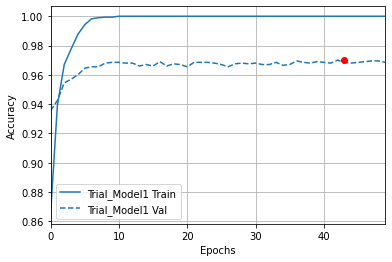

In [55]:
#Plot training Data
model_histories={}
model_histories["trial_model1"]=history1
plotter=tfdocs.plots.HistoryPlotter(metric="accuracy")
plotter.plot(model_histories)
plt.plot(43,0.97,"ro")

In [56]:
#Build model with optimal hyperparameters
#Learning rate: 0.001
#Neurons in hidden layer: 448
#Training epochs: 43
model1=tuner.hypermodel.build(best_hps)
model1.fit(test_data2D,test_label,epochs=perf_epoch,validation_split=0.2)

Epoch 1/43
250/250 [==============================] - 1s 4ms/step - loss: 0.4745 - accuracy: 0.8615 - val_loss: 0.2164 - val_accuracy: 0.9320
Epoch 2/43
250/250 [==============================] - 1s 4ms/step - loss: 0.1925 - accuracy: 0.9452 - val_loss: 0.1640 - val_accuracy: 0.9485
Epoch 3/43
250/250 [==============================] - 1s 4ms/step - loss: 0.1235 - accuracy: 0.9659 - val_loss: 0.1560 - val_accuracy: 0.9520
Epoch 4/43
250/250 [==============================] - 1s 4ms/step - loss: 0.0736 - accuracy: 0.9809 - val_loss: 0.1346 - val_accuracy: 0.9590
Epoch 5/43
250/250 [==============================] - 1s 4ms/step - loss: 0.0465 - accuracy: 0.9890 - val_loss: 0.1402 - val_accuracy: 0.9585
Epoch 6/43
250/250 [==============================] - 1s 4ms/step - loss: 0.0312 - accuracy: 0.9935 - val_loss: 0.1200 - val_accuracy: 0.9645
Epoch 7/43
250/250 [==============================] - 1s 4ms/step - loss: 0.0209 - accuracy: 0.9960 - val_loss: 0.1217 - val_accuracy: 0.9670
Epoch 

In [58]:
#Evaluate the model on the test Data
result1=model1.evaluate(test_data2D,test_label)

313/313 [==============================] - 1s 2ms/step - loss: 0.0348 - accuracy: 0.9937


In [59]:
#Save model
model1.save("DigitCLass_Model")

INFO:tensorflow:Assets written to: DigitCLass_Model/assets


In [60]:
check=tf.keras.models.load_model("DigitCLass_Model")
check.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 448)               351680    
_________________________________________________________________
dense_1 (Dense)              (None, 10)                4490      
Total params: 356,170
Trainable params: 356,170
Non-trainable params: 0
_________________________________________________________________


In [78]:
#Make an evaluation function
def model_eval(index,test_set,test_labels,model):
    all_predictions=model.predict(test_set)
    prediction_array=all_predictions[index]
    plt.subplot(1,2,1)
    plt.imshow(test_set[index])
    plt.subplot(1,2,2)
    plt.xticks(range(10))
    plt.yticks([])
    plt.bar(range(10),prediction_array)
    plt.ylim([0, 1])
    plt.show()
    prediction=np.argmax(prediction_array)
    true_val=test_labels[index]
    print(f"Predicted digit:{prediction}\nExpected value:{true_val}")

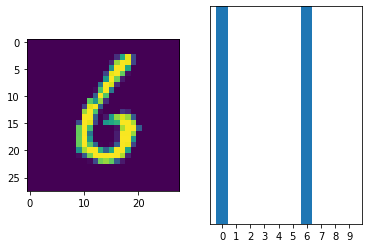

Predicted digit:6
Expected value:6


In [81]:
model_eval(50,test_data2D,test_label,model1)